# Seoul Bike Dataset: Predicting Bike Rental Demand
This notebook builds a decision tree regression workflow to predict rented bike counts from weather, calendar, and seasonal features.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

## Data Inspection
The data is loaded, filtered to functioning rental days, and split into training and test sets after deriving useful date-based attributes.


In [2]:
bike = pd.read_csv("../data/seoul_bike.csv", encoding="unicode_escape")
bike = bike[bike["Functioning Day"] == "Yes"]

bike["Date"] = pd.to_datetime(bike["Date"], format="%d/%m/%Y")

bike["Month"] = bike["Date"].dt.month
bike["Day"] = bike["Date"].dt.day

X = bike.drop(["Date", "Rented Bike Count", "Functioning Day"], axis=1)
y = bike["Rented Bike Count"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train.hist(figsize=(14, 10), bins=30)
X_train.info()




<class 'pandas.core.frame.DataFrame'>
Index: 6772 entries, 8691 to 7469
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Hour                       6772 non-null   int64  
 1   Temperature(°C)            6772 non-null   float64
 2   Humidity(%)                6772 non-null   int64  
 3   Wind speed (m/s)           6772 non-null   float64
 4   Visibility (10m)           6772 non-null   int64  
 5   Dew point temperature(°C)  6772 non-null   float64
 6   Solar Radiation (MJ/m2)    6772 non-null   float64
 7   Rainfall(mm)               6772 non-null   float64
 8   Snowfall (cm)              6772 non-null   float64
 9   Seasons                    6772 non-null   object 
 10  Holiday                    6772 non-null   object 
 11  Month                      6772 non-null   int32  
 12  Day                        6772 non-null   int32  
dtypes: float64(6), int32(2), int64(3), object(2)
memor

## Preprocessing
Numerical features are standardized and categorical features are encoded so the regression model can consume a consistent feature matrix.


In [3]:
num_pipeline = make_pipeline(
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64", "int64"]).columns),
    ("cat", cat_pipeline, X_train.select_dtypes(include=["object"]).columns)
])


## Model Selection
A decision tree regressor is tuned with cross-validation, including cost-complexity pruning through the `ccp_alpha` parameter.


In [4]:
tree = make_pipeline(
    preprocessing,
    DecisionTreeRegressor()
)

kfold = KFold(5, shuffle=True, random_state=42)

tree_grid = GridSearchCV(
    tree,
    {"decisiontreeregressor__max_depth": range(10, 15)},
    refit=True,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

tree_grid.fit(X_train, y_train)
reg = tree_grid.best_estimator_


X_train_prep = reg[:-1].transform(X_train)
ccp_path = reg[-1].cost_complexity_pruning_path(X_train_prep, y_train) # compute alphas

grid = GridSearchCV(
    reg,
    {"decisiontreeregressor__ccp_alpha": ccp_path.ccp_alphas},
    refit=True,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train , y_train)


,estimator,Pipeline(step...x_depth=10))])
,param_grid,{'decisiontreeregressor__ccp_alpha': array([0.0000...14805613e+05])}
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## Evaluation
The selected model is evaluated on the held-out test set using regression metrics such as R2, MSE, RMSE, and MAE.


Test R2: 0.7950482864171382
Test MSE: 80461.24771039031
Test RMSE: 283.65691902435645
Test MAE: 178.32408274900973


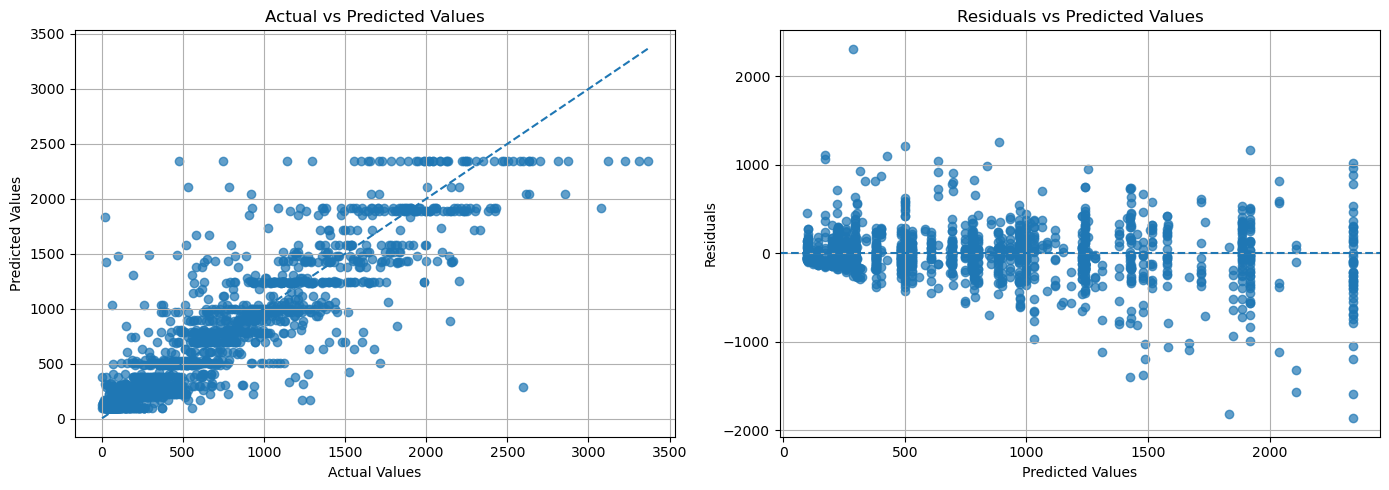

In [6]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted Values")
axes[0].grid(True)

# 2. Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].grid(True)

plt.tight_layout()
plt.show()
